# generate results for Fig.3

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator, NullLocator
plt.rc('font',family='Arial')
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['font.size'] = 10
import matplotlib.colors as mcolors

import seaborn as sns

import palettable.colorbrewer.sequential as palet

import time
start_time = time.time()
print(time.ctime())

from dynamic_stock_model import DynamicStockModel

file_path = 'C:/Users/xmuxi/Desktop/2-UCAS/4-Co-Ni-Cu/Data/'

Sun Aug  2 16:00:27 2026


- population (million persons)

In [2]:
df_pop = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='Population', index_col=[0], header=2)
df_pop.head(2)

,China,Japan,EU,USA,RoW,World
Region,,,,,,
1900,400.265000,44.103,278.2490,76.391,527.86193,1326.869930
1901,402.520077,44.662,280.5497,77.888,532.84672,1338.466497


In [3]:
Materials = ['Cobalt','Nickel','Copper']

IEA_Scenarios = ['STEPS','APS','NZES']

Regions = ['China','Japan','EU','USA','RoW']
Region_Colors = ['#D62728','#2CA02C','#FF7F0E','#1F77B4','#7F7F7F']

Primary_Scenarios = ['Baseline (SP)','Copper-driven','Laterite Nickel-driven','All carriers-driven']
Secondary_Scenarios = ['Constant','High']
Process_Scenarios = ['Constant','Efficient']
Lifetime_Scenarios = ['Constant','Longer']

Segment_Scenarios = ['Baseline']
#Segment_Scenarios = ['Baseline','Smaller','Larger']

Battery_Sizes = ['Larger']
#Battery_Sizes = ['Constant','Larger']

Battery_Scenarios = ['Baseline','NMC', 'NMA', 'LFP/LMFP', 'Na-ion']

Mining_Scenarios = ['Baseline (SP)','Copper-driven','Laterite Nickel-driven','All Carrier-driven']
Mining_Sources = ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']

Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','Metal Goods & Others','B-CEs','B-EVs','B-ESS',]

## Demand: Bottom-up (Emerging use)

In [4]:
Year_Min = 2025

def full_fill(df):
    df_temp = pd.DataFrame(index=np.arange(Year_Min,df.index.min()), columns=df.columns)
    df_temp.fillna(value=0, inplace=True)
    df_output  = pd.concat([df_temp, df])
    
    return df_output

- ESS (kt)

In [5]:
df_ESS_stock = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_stock', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_stock = df_ESS_stock.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_stock = df_ESS_stock.T
df_ESS_stock = full_fill(df_ESS_stock)

df_ESS_inflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_inflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_inflow = df_ESS_inflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_inflow = df_ESS_inflow.T
df_ESS_inflow = full_fill(df_ESS_inflow)

df_ESS_outflow = pd.read_excel(file_path + 'Sector_ESS/5Regions/ESS_Output.xlsx', sheet_name='material_outflow', index_col=[0,1,2,3,4,5], header=[0])
df_ESS_outflow = df_ESS_outflow.groupby(['Material','ESS Scenario','Battery Scenario','Lifetime']).sum()
df_ESS_outflow = df_ESS_outflow.T
df_ESS_outflow = full_fill(df_ESS_outflow)

df_ESS_inflow.head(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no l

Material            Cobalt                                                    \
ESS Scenario           APS                                                     
Battery Scenario  Baseline            LFP/LMFP                 NMA             
Lifetime          Constant    Longer  Constant    Longer  Constant    Longer   
2010              0.090164  0.090164  0.090164  0.090164  0.090164  0.090164   
2011              0.037165  0.037165  0.037165  0.037165  0.037165  0.037165   

Material                                                  ...    Nickel  \
ESS Scenario                                              ...     STEPS   
Battery Scenario       NMC              Na-ion            ...  LFP/LMFP   
Lifetime          Constant    Longer  Constant    Longer  ...  Constant   
2010              0.090164  0.090164  0.090164  0.090164  ...  0.266726   
2011              0.037165  0.037165  0.037165  0.037165  ...  0.109941   

Material                                                                      \
ESS Scenario                                                                   
Battery Scenario                 NMA                 NMC              Na-ion   
Lifetime            Longer  Constant    Longer  Constant    Longer  Constant   
2010              0.266726  0.266726  0.266726  0.266726  0.266726  0.266726   
2011              0.109941  0.109941  0.109941  0.109941  0.109941  0.109941   

Material                                        
ESS Scenario                                    
Battery Scenario           Optimized            
Lifetime            Longer  Constant    Longer  
2010              0.266726  0.266726  0.266726  
2011              0.109941  0.109941  0.109941  

[2 rows x 108 columns]

- vehicle: battery material (kt)

In [6]:
df_EV_stock = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_stock', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_stock = df_EV_stock.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_stock = df_EV_stock.T
df_EV_stock = full_fill(df_EV_stock)

df_EV_inflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_inflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_inflow = df_EV_inflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_inflow = df_EV_inflow.T
df_EV_inflow = full_fill(df_EV_inflow)

df_EV_outflow = pd.read_excel(file_path + 'Sector_Vehicle/5Regions/Vehicle_Output.xlsx', sheet_name='battery_material_outflow', index_col=[0,1,2,3,4,5,6,7], header=[0])
df_EV_outflow = df_EV_outflow.groupby(['Material','Powertrain Scenario','Segment Scenario','Battery Size','Battery Scenario','Lifetime']).sum()
df_EV_outflow = df_EV_outflow.T
df_EV_outflow = full_fill(df_EV_outflow)

df_EV_outflow.head(2)

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output  = pd.concat([df_temp, df])
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\3978719790.py:6: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no l

Material               Cobalt                                          \
Powertrain Scenario       APS                                           
Segment Scenario     Baseline                                           
Battery Size           Larger                                           
Battery Scenario     Baseline            LFP/LMFP                 NMA   
Lifetime             Constant    Longer  Constant    Longer  Constant   
2005                 0.000006  0.000006  0.000006  0.000006  0.000006   
2006                 0.000020  0.000020  0.000020  0.000020  0.000020   

Material                                                               ...  \
Powertrain Scenario                                                    ...   
Segment Scenario                                                       ...   
Battery Size                                                           ...   
Battery Scenario                    NMC              Na-ion            ...   
Lifetime               Longer  Constant    Longer  Constant    Longer  ...   
2005                 0.000006  0.000006  0.000006  0.000006  0.000006  ...   
2006                 0.000020  0.000020  0.000020  0.000020  0.000020  ...   

Material               Nickel                                          \
Powertrain Scenario     STEPS                                           
Segment Scenario     Baseline                                           
Battery Size           Larger                                           
Battery Scenario     LFP/LMFP                 NMA                 NMC   
Lifetime             Constant    Longer  Constant    Longer  Constant   
2005                 0.000009  0.000009  0.000009  0.000009  0.000009   
2006                 0.000029  0.000029  0.000029  0.000029  0.000029   

Material                                                               
Powertrain Scenario                                                    
Segment Scenario                                                       
Battery Size                                                           
Battery Scenario                 Na-ion           Optimized            
Lifetime               Longer  Constant    Longer  Constant    Longer  
2005                 0.000009  0.000009  0.000009  0.000009  0.000009  
2006                 0.000029  0.000029  0.000029  0.000029  0.000029  

[2 rows x 108 columns]

## Copper cycle

In [7]:
Cu_Sectors = ['Building & Construction','Infrastructure','Transport','Industrial Equipment','Other Products']

Cu_New_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)', 'B-ESS', 'B-EVs']
Cu_Old_Sectors = ['Building & Construction','Infrastructure','Transport (Exclude B-EVs)','Industrial Equipment','Other Products (Exclude B-ESS)']
Cu_Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','B-CEs','B-EVs','B-ESS',]

Cu_sector_color_dict = {'Building & Construction': '#C6DBEF', 
                     'Infrastructure': '#9ECAE1', 
                     'Building & Infrastructure': '#C6DBEF', 
                     
                     'Transport': '#6BAED6', 
                     'Transport (Exclude B-EVs)': '#6BAED6', 
                     'Transportation': '#6BAED6', 
                     
                     'Industrial Equipment': '#3182BD',
                     
                     'Other Products':'#08519C',  
                     'Other Products (Exclude B-ESS)':'#08519C',
                     
                     'B-CEs': '#FDAE6B',
                     'B-EVs': '#F16913',
                     'B-ESS': '#8C2D04'}

Cu_New_Sector_Colors = [Cu_sector_color_dict[s] for s in Cu_New_Sectors]
Cu_Agg_Sector_Colors = [Cu_sector_color_dict[s] for s in Cu_Agg_Sectors]

- Copper per capita stock (kg/person)

In [8]:
df_Cu_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Cu_per_capita = df_Cu_per_capita.loc[:2050:]
df_Cu_per_capita.tail(2)

,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),Total
Sector,,,,,,
2049,51.025553,18.937606,7.981351,8.650224,7.054912,93.649647
2050,51.235015,19.378207,8.327024,8.856932,7.322852,95.120030


- lifetime

In [9]:
df_Cu_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_Cu_lifetime = df_Cu_lifetime.T
df_Cu_lifetime.head(2)

Lifetime Scenario                Constant                                 \
Sector            Building & Construction Infrastructure B-EVs Transport   
1900                                 40.0           34.0   NaN      17.0   
1901                                 40.0           34.0   NaN      17.0   

Lifetime Scenario                                                       \
Sector            Transport (Exclude B-EVs) Industrial Equipment B-ESS   
1900                                   17.0                 17.0   NaN   
1901                                   17.0                 17.0   NaN   

Lifetime Scenario                                                \
Sector            Other Products Other Products (Exclude B-ESS)   
1900                        13.0                           13.0   
1901                        13.0                           13.0   

Lifetime Scenario                  Longer                                 \
Sector            Building & Construction Infrastructure B-EVs Transport   
1900                                 40.0           34.0   NaN      17.0   
1901                                 40.0           34.0   NaN      17.0   

Lifetime Scenario                                                       \
Sector            Transport (Exclude B-EVs) Industrial Equipment B-ESS   
1900                                   17.0                 17.0   NaN   
1901                                   17.0                 17.0   NaN   

Lifetime Scenario                                                
Sector            Other Products Other Products (Exclude B-ESS)  
1900                        13.0                           13.0  
1901                        13.0                           13.0

- Copper Traditional use 
- stock, inflow, outflow
- million persons * kg/person = kt

In [10]:
def cal_traditional_stock_flow(df_pop, df_capita, df_lt, Old_Sectors):
    
    df_stock = pd.DataFrame(index=df_capita.index, 
                             columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_inflow = df_stock.copy()
    df_outflow = df_inflow.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            df_stock[(lt,s)] = df_pop['World'] * df_capita[s]
            ## stock-driven
            DSM = DynamicStockModel(t = list(df_stock.index), 
                                    s = list(df_stock[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_stock_driven_model()
            DSM.compute_outflow_total()
            ## fill in
            df_inflow[(lt,s)] = DSM.i
            df_outflow[(lt,s)] = DSM.o
                
    ## 第二轮
    df_inflow_2 = df_inflow.mask(df_inflow<0, 0)
    df_stock_2 = pd.DataFrame(index=df_capita.index, 
                              columns=pd.MultiIndex.from_product([Lifetime_Scenarios,Old_Sectors],names=['Lifetime','Sector']))
    df_outflow_2 = df_stock_2.copy()
    
    for lt in Lifetime_Scenarios:
        for s in Old_Sectors:
            ## inflow-driven
            DSM = DynamicStockModel(t = list(df_inflow_2.index), 
                                    i = list(df_inflow_2[(lt,s)]), 
                                    lt = {'Type': 'Normal',
                                          'Mean': list(df_lt[(lt,s)]),    
                                          'StdDev': list(0.3 * df_lt[(lt,s)])})
            DSM.compute_s_c_inflow_driven()
            DSM.compute_stock_total()
            DSM.compute_o_c_from_s_c()
            DSM.compute_outflow_total()
            ## fill in 
            df_stock_2[(lt,s)] = DSM.s
            df_outflow_2[(lt,s)] = DSM.o
                
    return df_stock_2, df_inflow_2, df_outflow_2


df_Cu_traditional_stock, df_Cu_traditional_inflow, df_Cu_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Cu_per_capita, df_Cu_lifetime, Cu_Old_Sectors)
df_Cu_traditional_stock = df_Cu_traditional_stock.loc[Year_Min:,:]
df_Cu_traditional_inflow = df_Cu_traditional_inflow.loc[Year_Min:,:]
df_Cu_traditional_outflow = df_Cu_traditional_outflow.loc[Year_Min:,:]
df_Cu_traditional_inflow.head(2)

Lifetime                Constant                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2025                 9289.358031    3494.316231               2287.131327   
2026                 9171.777626    3542.086418               2344.233269   

Lifetime                                                      \
Sector   Industrial Equipment Other Products (Exclude B-ESS)   
Sector                                                         
2025              2877.911034                    2558.271193   
2026              2942.644061                    2629.279972   

Lifetime                  Longer                                           \
Sector   Building & Construction Infrastructure Transport (Exclude B-EVs)   
Sector                                                                      
2025                 9289.332077    3494.306335               2287.120192   
2026                 9171.704965    3542.054976               2344.178537   

Lifetime                                                      
Sector   Industrial Equipment Other Products (Exclude B-ESS)  
Sector                                                        
2025              2877.892932                    2558.248508  
2026              2942.564473                    2629.161311

- dissipation loss rate

In [11]:
df_Cu_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_Cu_dissipation_rate

,Dissipation rate
Sector,
Building & Construction,0.002
Infrastructure,0.006
Transport,0.004
Transport (Exclude B-EVs),0.004
B-EVs,0.004
Industrial Equipment,0.000
Other Products,0.020
Other Products (Exclude B-ESS),0.020
B-ESS,0.020


- loss rate

In [12]:
df_Cu_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_Cu_parameters = df_Cu_parameters.T
df_Cu_parameters = df_Cu_parameters.loc[Year_Min:,:]
df_Cu_parameters.head(2)

Scenario          Constant                                            \
Loss rate mining loss rate benefication loss rate smelting loss rate   
2025               0.06945                 0.1346             0.0129   
2026               0.06945                 0.1346             0.0129   

Scenario                                                   \
Loss rate refining loss rate primary processing loss rate   
2025                  0.0051                         0.06   
2026                  0.0051                         0.06   

Scenario                                                     \
Loss rate manufacturing loss rate new scrap collection rate   
2025                         0.17                      0.92   
2026                         0.17                      0.92   

Scenario                                                        Efficient  \
Loss rate old scrap collection rate recycling efficiency mining loss rate   
2025                           0.45                 0.92         0.065977   
2026                           0.45                 0.92         0.062679   

Scenario                                                                \
Loss rate benefication loss rate smelting loss rate refining loss rate   
2025                    0.127870           0.012255           0.004845   
2026                    0.121476           0.011642           0.004603   

Scenario                                                        \
Loss rate primary processing loss rate manufacturing loss rate   
2025                           0.05700                0.161500   
2026                           0.05415                0.153425   

Scenario                                                       \
Loss rate new scrap collection rate old scrap collection rate   
2025                       0.929200                  0.454500   
2026                       0.938492                  0.459045   

Scenario                        
Loss rate recycling efficiency  
2025                  0.929200  
2026                  0.938492

- scrap ratio

In [13]:
df_Cu_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Copper_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)
df_Cu_scrap_ratio

,Value
Indicator,
Clean scrap ratio of new scrap,0.90
Clean scrap ratio of old scrap,0.33


## Nickel cycle

In [14]:
Ni_Sectors = ['Building & Infrastructure','Transportation','Industrial Machinery','Applications & Electronics','Metal Goods & Others']
Ni_New_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others','B-ESS','B-EVs']
Ni_Old_Sectors = ['Building & Infrastructure','Transportation (Exclude B-EVs)','Industrial Machinery','Applications & Electronics (Exclude B-ESS)','Metal Goods & Others']
Ni_Agg_Sectors = ['Building & Infrastructure','Transportation','Industrial Equipment','Metal Goods & Others','B-CEs','B-EVs','B-ESS',]

Ni_sector_color_dict = {'Building & Infrastructure': '#C6DBEF', 
                        
                    'Transportation': '#6BAED6', 
                    'Transportation (Exclude B-EVs)': '#6BAED6', 
                        
                    'Industrial Machinery': '#3182BD', 
                    'Industrial Equipment': '#3182BD', 
                        
                    'Applications & Electronics':'#31A354', 
                    'Applications & Electronics (Exclude B-ESS)':'#31A354', 
                        
                    'Metal Goods & Others':'#08519C', 
                        
                    'Power Plant': '#BCBDDC',
                     
                    'B-CEs': '#FDAE6B',
                    'B-EVs': '#F16913',
                    'B-ESS': '#8C2D04',}

Ni_New_Sector_Colors = [Ni_sector_color_dict[s] for s in Ni_New_Sectors]
Ni_Agg_Sector_Colors = [Ni_sector_color_dict[s] for s in Ni_Agg_Sectors]

- Nickel per capita (kg/person)

In [15]:
df_Ni_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Ni_per_capita = df_Ni_per_capita.loc[:2050:]
df_Ni_per_capita.tail(2)

,Building & Infrastructure,Transportation (Exclude B-EVs),Industrial Machinery,Applications & Electronics (Exclude B-ESS),Metal Goods & Others,Total
Sector,,,,,,
2049,2.224502,2.250602,4.045783,1.158639,2.101553,11.781080
2050,2.260995,2.301909,4.094573,1.175339,2.173898,12.006714


- lifetime

In [16]:
df_Ni_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=2)
df_Ni_lifetime = df_Ni_lifetime.T
df_Ni_lifetime.head(2)

Scenario                  Constant                 \
Sector   Building & Infrastructure Transportation   
1900                          30.0           25.0   
1901                          30.0           25.0   

Scenario                                                            \
Sector   Transportation (Exclude B-EVs) B-EVs Industrial Machinery   
1900                               25.0   NaN                 50.0   
1901                               25.0   NaN                 50.0   

Scenario                             \
Sector   Applications & Electronics   
1900                           14.0   
1901                           14.0   

Scenario                                                   \
Sector   Applications & Electronics (Exclude B-ESS) B-ESS   
1900                                           14.0   NaN   
1901                                           14.0   NaN   

Scenario                                         Longer                 \
Sector   Metal Goods & Others Building & Infrastructure Transportation   
1900                     15.0                      50.0           18.0   
1901                     15.0                      50.0           18.0   

Scenario                                                            \
Sector   Transportation (Exclude B-EVs) B-EVs Industrial Machinery   
1900                               18.0   NaN                 25.0   
1901                               18.0   NaN                 25.0   

Scenario                             \
Sector   Applications & Electronics   
1900                           15.0   
1901                           15.0   

Scenario                                                                        
Sector   Applications & Electronics (Exclude B-ESS) B-ESS Metal Goods & Others  
1900                                           15.0   NaN                 15.0  
1901                                           15.0   NaN                 15.0

- Nickel Traditional use 
- stock, inflow, outflow
- million persons * kg/person = kt

In [17]:
df_Ni_traditional_stock, df_Ni_traditional_inflow, df_Ni_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Ni_per_capita, df_Ni_lifetime, Ni_Old_Sectors)
df_Ni_traditional_stock = df_Ni_traditional_stock.loc[Year_Min:,:]
df_Ni_traditional_inflow = df_Ni_traditional_inflow.loc[Year_Min:,:]
df_Ni_traditional_outflow = df_Ni_traditional_outflow.loc[Year_Min:,:]
df_Ni_traditional_inflow.tail(2)

Lifetime                  Constant                                 \
Sector   Building & Infrastructure Transportation (Exclude B-EVs)   
Sector                                                              
2049                    896.122979                    1107.113630   
2050                    911.254961                    1131.030942   

Lifetime                                                                  \
Sector   Industrial Machinery Applications & Electronics (Exclude B-ESS)   
Sector                                                                     
2049               995.646879                                 825.986729   
2050              1010.920424                                 841.377391   

Lifetime                                         Longer  \
Sector   Metal Goods & Others Building & Infrastructure   
Sector                                                    
2049              1626.748474                868.497251   
2050              1690.842975                878.312385   

Lifetime                                                      \
Sector   Transportation (Exclude B-EVs) Industrial Machinery   
Sector                                                         
2049                        1050.989459            990.31210   
2050                        1065.464498           1004.50762   

Lifetime                                                                  
Sector   Applications & Electronics (Exclude B-ESS) Metal Goods & Others  
Sector                                                                    
2049                                     720.975036          1462.726610  
2050                                     730.148879          1512.541069

- dissipation loss rate

In [18]:
df_Ni_dissipation_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='dissipation', index_col=[0], header=2)
df_Ni_dissipation_rate.fillna(0, inplace=True)
df_Ni_dissipation_rate

,Dissipation rate
Sector,
Building & Infrastructure,0.0001
Transportation,0.0001
Transportation (Exclude B-EVs),0.0001
B-EVs,0.0001
Industrial Machinery,0.0000
Applications & Electronics,0.0000
Applications & Electronics (Exclude B-ESS),0.0000
B-ESS,0.0000
Metal Goods & Others,0.0050


- loss rate

In [19]:
df_Ni_parameters = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='parameters', index_col=[0,1], header=2)
df_Ni_parameters = df_Ni_parameters.T
df_Ni_parameters = df_Ni_parameters.loc[Year_Min:,:]
df_Ni_parameters.head(2)

Scenario          Constant                                        \
Loss rate mining loss rate smelting loss rate refining loss rate   
2025              0.143398           0.056408           0.043997   
2026              0.143398           0.056408           0.043997   

Scenario                                                        \
Loss rate primary processing loss rate manufacturing loss rate   
2025                              0.21                    0.14   
2026                              0.21                    0.14   

Scenario                                                       \
Loss rate new scrap collection rate old scrap collection rate   
2025                           0.86                      0.63   
2026                           0.86                      0.63   

Scenario                              Efficient                     \
Loss rate recycling efficiency mining loss rate smelting loss rate   
2025                       1.0         0.136228           0.053588   
2026                       1.0         0.129417           0.050908   

Scenario                                                   \
Loss rate refining loss rate primary processing loss rate   
2025                0.041797                     0.199500   
2026                0.039707                     0.189525   

Scenario                                                     \
Loss rate manufacturing loss rate new scrap collection rate   
2025                      0.13300                  0.868600   
2026                      0.12635                  0.877286   

Scenario                                                  
Loss rate old scrap collection rate recycling efficiency  
2025                       0.636300                  1.0  
2026                       0.642663                  1.0

- scrap ratio

In [20]:
df_Ni_scrap_ratio = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Nickel_compile_data_world.xlsx', sheet_name='scrap ratio', index_col=[0], header=2)
df_Ni_scrap_ratio

,Value
Indicator,
Clean scrap ratio of new scrap,1.000000
Clean scrap ratio of old scrap,0.981333


## Cobalt cycle

In [21]:
Co_Sectors = ['Battery','S&A','C&C','MAG','CAT','PI&E','OTH']
Co_New_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs','B-ESS','B-EVs']
Co_Old_Sectors = ['S&A','C&C','MAG','CAT','PI&E','OTH','B-CEs']
Co_Agg_Sectors = ['Metal Goods & Others','B-CEs','B-EVs','B-ESS']

Co_sector_color_dict = {'S&A': '#FDD0A2',
                     'C&C': '#FDAE6B',
                     'MAG': '#FD8D3C',
                     'CAT': '#F16913',
                     'PI&E': '#D94801',
                     'OTH': '#8C2D04', 
                     
                     'Metal Goods & Others':'#08519C',
                     
                     'B-CEs': '#FDAE6B',
                    'B-EVs': '#F16913',
                    'B-ESS': '#8C2D04', }

Co_New_Sector_Colors = [Co_sector_color_dict[s] for s in Co_New_Sectors]
Co_Agg_Sector_Colors = [Co_sector_color_dict[s] for s in Co_Agg_Sectors]

- lifetime

In [22]:
df_Co_lifetime = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='lifetime', index_col=[0,1], header=[2])
df_Co_lifetime = df_Co_lifetime.T
df_Co_lifetime.head(2)

Lifetime Constant                                                  Longer  \
Sector    Battery B-EVs B-ESS B-CEs  S&A  C&C  MAG  CAT PI&E  OTH Battery   
1988          3.0   NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0     3.0   
1989          3.0   NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0     3.0   

Lifetime                                                  
Sector   B-EVs B-ESS B-CEs  S&A  C&C  MAG  CAT PI&E  OTH  
1988       NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0  
1989       NaN   NaN   3.0  5.0  1.0  5.0  5.5  5.0  1.0

- Cobalt per capita (kg/1000 persons)

In [23]:
df_Co_per_capita = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='per capita traditional use', index_col=[0], header=[5])
df_Co_per_capita.head(2)

,B-CEs,S&A,C&C,MAG,CAT,PI&E,OTH,Total
Sector,,,,,,,,
1988,0.767447,0.948708,0.521633,0.335234,0.323229,0.398726,1.109249,4.404226
1989,1.465547,1.820370,0.746412,0.643243,0.620410,0.765071,1.587239,7.648293


- Cobalt Traditional use 
- stock, inflow, outflow
- million persons * kg/1000 persons = t
- from t to kt

In [24]:
df_Co_traditional_stock, df_Co_traditional_inflow, df_Co_traditional_outflow = cal_traditional_stock_flow(df_pop, df_Co_per_capita, df_Co_lifetime, Co_Old_Sectors)

df_Co_traditional_stock = df_Co_traditional_stock / 1e3  # from t to kt 
df_Co_traditional_inflow = df_Co_traditional_inflow / 1e3  # from t to kt 
df_Co_traditional_outflow = df_Co_traditional_outflow / 1e3  # from t to kt 

df_Co_traditional_stock = df_Co_traditional_stock.loc[Year_Min:,:]
df_Co_traditional_inflow = df_Co_traditional_inflow.loc[Year_Min:,:]
df_Co_traditional_outflow = df_Co_traditional_outflow.loc[Year_Min:,:]
df_Co_traditional_inflow.head(2)

Lifetime   Constant                                                     \
Sector          S&A        C&C       MAG       CAT      PI&E       OTH   
Sector                                                                   
2025      20.515316  13.898023  6.036324  7.385298  7.810709  7.784252   
2026      21.935407  14.356479  5.945936  7.450327  7.727639  7.984319   

Lifetime                Longer                                           \
Sector        B-CEs        S&A        C&C       MAG       CAT      PI&E   
Sector                                                                    
2025      77.513555  20.513936  13.724184  6.036063  7.384935  7.810313   
2026      73.702939  21.920745  14.082430  5.942845  7.446708  7.723154   

Lifetime                       
Sector         OTH      B-CEs  
Sector                         
2025      7.684163  77.489229  
2026      7.832235  73.361048

In [25]:
df_Co_traditional_inflow.tail(2)

Lifetime  Constant                                                         \
Sector         S&A        C&C        MAG        CAT       PI&E        OTH   
Sector                                                                      
2049      61.92074  30.418709  11.716639  12.278807  13.390125  12.170797   
2050      62.16483  30.539208  11.764195  12.331159  13.444286  12.216947   

Lifetime                 Longer                                             \
Sector         B-CEs        S&A        C&C       MAG        CAT       PI&E   
Sector                                                                       
2049      138.780657  50.593974  25.351530  9.563650  10.053514  10.930543   
2050      139.262225  50.364001  25.288849  9.522207  10.004073  10.882635   

Lifetime                         
Sector          OTH       B-CEs  
Sector                           
2049      10.143008  113.262851  
2050      10.116422  112.663952

- loss rate

In [26]:
df_Co_loss_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='loss rate', index_col=[0,1,2], header=[2])
df_Co_loss_rate = df_Co_loss_rate.T
df_Co_loss_rate = df_Co_loss_rate.loc[Year_Min:,:]
df_Co_loss_rate.head(2)

Scenario  Constant                                                             \
Stage       Mining Refining Manufacturing                                       
Loss rate      All      All       Battery B-EVs B-ESS B-CEs   S&A   C&C   MAG   
2025          0.35      0.2          0.01  0.01  0.01  0.01  0.16  0.01  0.02   
2026          0.35      0.2          0.01  0.01  0.01  0.01  0.16  0.01  0.02   

Scenario         ...     Efficient                                        \
Stage            ... Manufacturing                                         
Loss rate   CAT  ...       Battery     B-EVs     B-ESS     B-CEs     S&A   
2025       0.05  ...      0.009900  0.009900  0.009900  0.009900  0.1520   
2026       0.05  ...      0.009801  0.009801  0.009801  0.009801  0.1444   

Scenario                                                     
Stage                                                        
Loss rate       C&C       MAG       CAT      PI&E       OTH  
2025       0.009900  0.019800  0.049500  0.009900  0.009900  
2026       0.009801  0.019602  0.049005  0.009801  0.009801  

[2 rows x 24 columns]

- recycling rate

In [27]:
df_Co_recycling_rate = pd.read_excel(file_path + 'Sector_Cu_Ni_Co/World/by-Cobalt_compile_data_world.xlsx', sheet_name='recycling rate', index_col=[0,1,2], header=[2])
df_Co_recycling_rate = df_Co_recycling_rate.T
df_Co_recycling_rate = df_Co_recycling_rate.loc[Year_Min:,:]
df_Co_recycling_rate.head(2)

Scenario                   Constant                                         \
Recycling New scrap generation rate                                          
Sector                      Battery B-EVs B-ESS B-CEs   S&A  C&C  MAG  CAT   
2025                           0.01  0.01  0.01  0.01  0.79  0.0  0.1  0.0   
2026                           0.01  0.01  0.01  0.01  0.79  0.0  0.1  0.0   

Scenario             ...               High                             \
Recycling            ... EoL recycling rate                              
Sector    PI&E  OTH  ...            Battery    B-EVs    B-ESS    B-CEs   
2025       0.0  0.0  ...            0.80800  0.80800  0.80800  0.10100   
2026       0.0  0.0  ...            0.81608  0.81608  0.81608  0.10201   

Scenario                                              
Recycling                                             
Sector         S&A       C&C      MAG  CAT PI&E  OTH  
2025       0.80800  0.454500  0.10100  0.0  0.0  0.0  
2026       0.81608  0.459045  0.10201  0.0  0.0  0.0  

[2 rows x 60 columns]

- Surplus

In [28]:
df_Co_Surplus = pd.read_excel(file_path + r'Sector_Cu_Ni_Co\World\by-Cobalt_compile_data_world.xlsx', sheet_name='Surplus', index_col=[0], header=[3])
df_Co_Surplus.fillna(value=0, inplace=True)
df_Co_Surplus = df_Co_Surplus / 1000  ## from ton to kt
df_Co_Surplus.loc[2020:2025]

,Cobalt surplus,Battery surplus
2020,0.0,0.0
2021,0.0,0.0
2022,0.0,14.2
2023,0.0,25.0
2024,0.0,36.0
2025,0.0,0.0


## By production

In [29]:
df_Primary_Baseline = pd.read_excel(file_path + 'Sector_Mining/Deposit_SP/Mining_Scenarios.xlsx',sheet_name='Baseline', header=1, index_col=[0])
df_Primary_Baseline = df_Primary_Baseline / 1e3  ## from t to kt
df_Primary_Baseline = df_Primary_Baseline.loc[Year_Min:,:]
df_Primary_Baseline.head(2)

,Total,Cobalt_from_Cobalt,Cobalt_from_Copper,Cobalt_from_Sulfide_Nickel,Cobalt_from_Laterite_Nickel
Year,,,,,
2025,288.869319,13.026317,239.719868,9.599075,26.524059
2026,304.828360,13.909072,252.908321,11.052875,26.958092


In [30]:
df_Nickel_Source = pd.read_excel(file_path + 'Sector_Mining/Deposit_SP/Mining_Scenarios.xlsx',sheet_name='Nickel', header=2, index_col=[0])
df_Nickel_Source = df_Nickel_Source.loc[Year_Min:,:]
df_Nickel_Source.head(2)

,Sulfide Nickel,Laterite Nickel
Year,,
2025,0.272581,0.727419
2026,0.269677,0.730323


In [31]:
df_IEA_prod_capacity = pd.read_excel(file_path + 'Sector_Mining/Cu_Ni_mining_capacity.xlsx', sheet_name='Mining', index_col=[0], header=2)
df_IEA_prod_capacity = df_IEA_prod_capacity.loc[Year_Min:,:]
df_IEA_prod_capacity

,Cobalt_SP,Cobalt,Nickel,Copper
Year,,,,
2025,288.869319,281.233333,3965.966667,23040.166667
2026,304.828360,289.126667,4070.933333,23286.333333
2027,318.111089,297.020000,4175.900000,23532.500000
2028,335.945150,304.913333,4280.866667,23778.666667
2029,349.494977,312.806667,4385.833333,24024.833333
2030,348.012589,320.700000,4490.800000,24271.000000
2031,336.049318,307.910000,4486.600000,23360.600000
2032,303.384701,295.120000,4482.400000,22450.200000
2033,319.012541,282.330000,4478.200000,21539.800000


## All Scenarios
- All inflows, outflows, stocks (kt)
### 人工测试

In [32]:
def rename_sector(row):
    
    if row.Material == 'Copper':
        if row.Sector in ['B-ESS','B-EVs','Industrial Equipment']:
            return row.Sector
        elif row.Sector in ['Building & Construction', 'Infrastructure']:
            return 'Building & Infrastructure'
        elif row.Sector == 'Transport (Exclude B-EVs)':
            return 'Transportation'
        elif row.Sector == 'Other Products (Exclude B-ESS)':
            return 'B-CEs'
        
    elif row.Material == 'Nickel':
        if row.Sector in ['B-ESS','B-EVs','Building & Infrastructure','Metal Goods & Others']:
            return row.Sector
        elif row.Sector == 'Transportation (Exclude B-EVs)':
            return 'Transportation'
        elif row.Sector == 'Industrial Machinery':
            return 'Industrial Equipment'
        elif row.Sector == 'Applications & Electronics (Exclude B-ESS)':
            return 'B-CEs'
        
    elif row.Material == 'Cobalt':
        if row.Sector in ['B-ESS','B-EVs','B-CEs']:
            return row.Sector
        else:
            return 'Metal Goods & Others'
        
        
def reconstruct_sector(df):
    df = df.copy()
    
    df = df.T.reset_index(drop=False)
    
    df.Sector = df.apply(rename_sector, axis=1)
    df = df.groupby(['Material','Sector']).sum().T
    
    return df

In [33]:
def extract_all_sectors(flow, lt, d_sce, seg_sce, b_size, b_sce):
    
    ################################## Copper
    df_copper = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Copper'],Cu_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Cu_Old_Sectors:
        if flow == 'Inflow':
            ## Lifetime, Sector
            df_copper[('Copper',s)] = df_Cu_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_copper[('Copper',s)] = df_Cu_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_copper[('Copper',s)] = df_Cu_traditional_stock[(lt,s)] 
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_copper[('Copper','B-ESS')] = df_ESS_inflow[('Copper',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_copper[('Copper','B-ESS')] = df_ESS_outflow[('Copper',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_copper[('Copper','B-ESS')] = df_ESS_stock[('Copper',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_copper[('Copper','B-EVs')] = df_EV_inflow[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_copper[('Copper','B-EVs')] = df_EV_outflow[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_copper[('Copper','B-EVs')] = df_EV_stock[('Copper',d_sce,seg_sce,b_size,b_sce,lt)]
                
    ################################## Nickel
    df_nickel = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Nickel'],Ni_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Ni_Old_Sectors:
        if flow == 'Inflow':
            df_nickel[('Nickel',s)] = df_Ni_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_nickel[('Nickel',s)] = df_Ni_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_nickel[('Nickel',s)] = df_Ni_traditional_stock[(lt,s)]
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_nickel[('Nickel','B-ESS')] = df_ESS_inflow[('Nickel',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_nickel[('Nickel','B-ESS')] = df_ESS_outflow[('Nickel',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_nickel[('Nickel','B-ESS')] = df_ESS_stock[('Nickel',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_nickel[('Nickel','B-EVs')] = df_EV_inflow[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_nickel[('Nickel','B-EVs')] = df_EV_outflow[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_nickel[('Nickel','B-EVs')] = df_EV_stock[('Nickel',d_sce,seg_sce,b_size,b_sce,lt)]
    
    ################################## Cobalt
    df_cobalt = pd.DataFrame(index=np.arange(Year_Min, 2050+1), 
                             columns=pd.MultiIndex.from_product([['Cobalt'],Co_New_Sectors],
                                                                names=['Material','Sector']))
    # fill traditional use
    for s in Co_Old_Sectors:
        if flow == 'Inflow':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_inflow[(lt,s)]
        elif flow == 'Outflow':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_outflow[(lt,s)]
        elif flow == 'Stock':
            df_cobalt[('Cobalt',s)] = df_Co_traditional_stock[(lt,s)]
    # fill ESS
    ## Material, ESS Scenario, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_inflow[('Cobalt',d_sce,b_sce,lt)]
    elif flow == 'Outflow':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_outflow[('Cobalt',d_sce,b_sce,lt)]
    elif flow == 'Stock':
        df_cobalt[('Cobalt','B-ESS')] = df_ESS_stock[('Cobalt',d_sce,b_sce,lt)]
    # fill battery
    ## Material, Powertrain Scenario, Segment Scenario, Battery Size, Battery Scenario, Lifetime
    if flow == 'Inflow':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_inflow[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Outflow':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_outflow[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
    elif flow == 'Stock':
        df_cobalt[('Cobalt','B-EVs')] = df_EV_stock[('Cobalt',d_sce,seg_sce,b_size,b_sce,lt)]
            
    ################################## 
    df_output = pd.concat([df_copper, df_nickel, df_cobalt], axis=1)
    
    return df_output


############################# 人工测试
lt='Longer'
d_sce='APS'  # IEA_Scenarios = ['STEPS','APS','NZES']
seg_sce='Baseline'
b_size='Larger'
b_sce='NMA'  # Battery_Scenarios = ['Baseline','NCM', 'NMA', 'LFP/LMFP', 'Na-ion']

df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)
df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)
df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=d_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
df_all_sector_stock_2 = reconstruct_sector(df_all_sector_stock)

df_all_sector_inflow_2.tail(2)

Material      Cobalt                                                   Copper  \
Sector         B-CEs      B-ESS       B-EVs Metal Goods & Others        B-CEs   
2049      113.262851  13.476596  325.466943           116.636220  5535.112548   
2050      112.663952  13.725680  340.754317           116.178187  5754.869555   

Material                                                     \
Sector         B-ESS        B-EVs Building & Infrastructure   
2049      245.385444  5926.188653              21314.241580   
2050      249.920835  6204.545228              21770.929277   

Material                                          Nickel              \
Sector   Industrial Equipment Transportation       B-CEs       B-ESS   
2049              5067.735915    5592.481572  720.975036  164.831462   
2050              5196.353324    5874.979021  730.148879  167.877996   

Material                                                              \
Sector          B-EVs Building & Infrastructure Industrial Equipment   
2049      3980.767240                868.497251            990.31210   
2050      4167.746225                878.312385           1004.50762   

Material                                      
Sector   Metal Goods & Others Transportation  
2049              1462.726610    1050.989459  
2050              1512.541069    1065.464498

In [34]:
df_all_sector_inflow['Copper'].tail(2)

Sector,Building & Construction,Infrastructure,Transport (Exclude B-EVs),Industrial Equipment,Other Products (Exclude B-ESS),B-ESS,B-EVs
2049,13438.093899,7876.147681,5592.481572,5067.735915,5535.112548,245.385444,5926.188653
2050,13658.769525,8112.159752,5874.979021,5196.353324,5754.869555,249.920835,6204.545228


In [35]:
df_all_sector_inflow['Cobalt'].tail(2)

Sector,S&A,C&C,MAG,CAT,PI&E,OTH,B-CEs,B-ESS,B-EVs
2049,50.593974,25.351530,9.563650,10.053514,10.930543,10.143008,113.262851,13.476596,325.466943
2050,50.364001,25.288849,9.522207,10.004073,10.882635,10.116422,112.663952,13.725680,340.754317


- Copper primary supply + secondary supply

In [36]:
def cal_world_copper_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce):

    df_inflow = df_all_inflow['Copper'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Copper'].T.groupby(['Sector']).sum().T
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_Cu_dissipation_rate.at[sector, 'Dissipation rate'])
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Cu_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_Cu_parameters[process_sce,'old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_Cu_parameters[process_sce,'manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_Cu_parameters[process_sce,'manufacturing loss rate'] * df_Cu_parameters[process_sce,'new scrap collection rate']
    df_world['P3_P4'] = df_world['P4_P3']*df_Cu_scrap_ratio.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_Cu_scrap_ratio.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_Cu_scrap_ratio.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_Cu_scrap_ratio.at['Clean scrap ratio of old scrap','Value'])) * (df_Cu_parameters[process_sce,'recycling efficiency'])
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1-df_Cu_parameters[process_sce,'refining loss rate']) / (1-df_Cu_parameters[process_sce,'smelting loss rate'])
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_Cu_parameters[process_sce,'benefication loss rate']) / (1-df_Cu_parameters[process_sce,'mining loss rate'])

    ################ 与统计数据进行比较
    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world


df_copper_temp = cal_world_copper_supply(df_all_sector_inflow, df_all_sector_outflow, secondary_sce='High', process_sce='Efficient')
df_copper_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,20054.144656,16335.886502,19987.330074,21214.425743,12641.659172,5745.634094,3796.731986,5313.118039,3929.817280
2026,19746.317585,16260.280069,20100.766885,21470.134192,13030.135009,5981.418325,3651.707861,5260.405123,4103.763737
2027,20071.459088,16697.933512,20738.177731,22236.541093,13436.309184,6229.549255,3596.299382,5292.420698,4297.131712
2028,20426.683069,17158.447155,21410.186318,23039.627117,13860.461304,6490.463226,3545.028420,5332.378442,4502.552182
2029,20916.378648,17730.960065,22154.968798,23886.451856,14301.735720,6764.070589,3463.725552,5349.496291,4670.268115
2030,21440.343058,18332.689034,22936.680148,24773.383290,14757.333283,7049.342992,3387.069293,5374.645551,4845.911180
2031,21438.604428,18481.428631,23272.000021,25225.391066,15222.589618,7344.304416,3253.195506,5351.496413,5022.291305
2032,22023.866527,19133.087628,24115.147707,26178.162348,15693.018727,7646.980752,3185.808310,5390.731128,5209.985125
2033,22633.130838,19806.496226,24983.988853,27158.371944,16164.799106,7955.641223,3120.011706,5433.372139,5401.669614
2034,23262.920181,20498.793094,25875.075128,28162.357014,16635.942465,8269.393556,3055.252642,5478.627251,5596.719498


- Nickel primary supply + secondary supply

In [37]:
def cal_world_nickel_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce):
    
    df_inflow = df_all_inflow['Nickel'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Nickel'].T.groupby(['Sector']).sum().T
    
    df_apc = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    for sector in df_apc.columns:
        df_apc[sector] = df_inflow[sector] / (1-df_Ni_dissipation_rate.at[sector, 'Dissipation rate'])
        
    ################# 起算点
    df_world = pd.DataFrame(index=df_apc.index)
    df_world['P4_P5'] = df_apc.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Ni_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] *  df_Ni_parameters[process_sce,'old scrap collection rate']
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    
    ################ 往前算
    df_world['Total_manufacturing_input'] = df_world['P4_P5'] / (1-df_Ni_parameters[process_sce,'manufacturing loss rate'])
    df_world['P4_P3'] = df_world['Total_manufacturing_input'] * df_Ni_parameters[process_sce,'manufacturing loss rate'] * df_Ni_parameters[process_sce,'new scrap collection rate']
    df_world['P3_P4'] = df_world['P4_P3']*df_Ni_scrap_ratio.at['Clean scrap ratio of new scrap','Value'] + df_world['P6_P3']*df_Ni_scrap_ratio.at['Clean scrap ratio of old scrap','Value']
    df_world['P2_P4'] = df_world['Total_manufacturing_input'] - df_world['P3_P4']
    df_world['P3_P2'] = (df_world['P4_P3'] * (1-df_Ni_scrap_ratio.at['Clean scrap ratio of new scrap','Value']) + df_world['P6_P3'] * (1-df_Ni_scrap_ratio.at['Clean scrap ratio of old scrap','Value'])) * (df_Ni_parameters[process_sce,'recycling efficiency'])
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2'])/ (1-df_Ni_parameters[process_sce,'refining loss rate']) / (1-df_Ni_parameters[process_sce,'smelting loss rate'])
    df_world['L0_P1'] = df_world['P1_P2'] / (1-df_Ni_parameters[process_sce,'mining loss rate'])

    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world


df_nickel_temp = cal_world_nickel_supply(df_all_sector_inflow, df_all_sector_outflow, secondary_sce='High', process_sce='Efficient')
df_nickel_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,3235.620135,2794.836643,2550.612915,3329.941775,1355.574059,862.551774,443.699570,1290.150378,16.100966
2026,3327.015090,2896.442710,2656.992628,3496.921446,1430.216279,919.147085,443.674880,1345.664552,17.157412
2027,3451.636076,3027.270642,2790.531966,3697.236977,1513.671390,982.508402,446.860616,1411.028861,18.340157
2028,3567.673160,3150.972999,2918.132244,3898.914531,1606.473881,1053.172992,449.088083,1482.601846,19.659229
2029,3710.711920,3298.975340,3068.694882,4130.736474,1708.717772,1131.404117,453.601405,1563.885978,21.119544
2030,3843.287286,3438.162637,3211.729104,4362.337536,1819.655999,1216.908952,456.857752,1651.051070,22.715634
2031,3951.063806,3555.402604,3334.844318,4580.519224,1937.689562,1308.803253,457.654197,1742.026456,24.430994
2032,4091.433239,3702.201275,3485.882934,4831.554356,2060.866139,1405.922312,460.689062,1840.367492,26.243883
2033,4242.589497,3859.158123,3646.887085,5096.550547,2187.315771,1507.108079,463.900326,1942.875721,28.132684
2034,4393.937211,4016.683009,3808.866637,5365.526816,2315.372235,1611.295181,466.347168,2047.564839,30.077510


- Cobalt primary supply + secondary supply

In [38]:
def cal_world_cobalt_supply(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce):
    
    df_inflow = df_all_inflow['Cobalt'].T.groupby(['Sector']).sum().T
    df_outflow = df_all_outflow['Cobalt'].T.groupby(['Sector']).sum().T
    
    ################# 起算点
    df_world = pd.DataFrame(index=df_inflow.index)
    df_world['P4_P5'] = df_inflow.sum(axis=1)
    
    ################# 往后算
    ## Outflow
    df_world['P5_P6'] = df_outflow.sum(axis=1)
    
    ## Secondary supply
    df_old_sec = pd.DataFrame(index=df_outflow.index, columns=df_outflow.columns)
    for sector in Co_New_Sectors:
        df_old_sec[sector] = df_outflow[sector] * df_Co_recycling_rate[(secondary_sce,'EoL recycling rate',sector)]
    df_world['P6_P3'] = df_old_sec.sum(axis=1)
    df_world['P3_P2'] = df_world['P6_P3']
    
    ################ 往前算
    df_manu = pd.DataFrame(index=df_inflow.index, columns=df_inflow.columns)
    df_manu_recycle = df_manu.copy()
    for sector in Co_New_Sectors:
        df_manu[sector] = df_inflow[sector] / (1 - df_Co_loss_rate[(process_sce,'Manufacturing',sector)])
        df_manu_recycle[sector] = df_manu[sector] * df_Co_recycling_rate[(secondary_sce,'New scrap generation rate',sector)] * df_Co_recycling_rate[(secondary_sce,'New scrap recycling efficiency',sector)]
        
    df_world['P4_P3'] = df_manu_recycle.sum(axis=1)
    df_world['P3_P4'] = df_world['P4_P3']
    df_world['P2_P4'] = df_manu.sum(axis=1) + df_sur['Battery surplus']
    
    df_world['P1_P2'] = (df_world['P2_P4']-df_world['P3_P2']) / (1 - df_Co_loss_rate[(process_sce,'Refining','All')])
    df_world['P1_P2'] = df_world['P1_P2'] + df_sur['Cobalt surplus'] 
    df_world['L0_P1'] = df_world['P1_P2'] / (1 - df_Co_loss_rate[(process_sce,'Mining','All')])
    
    df_world = df_world[['L0_P1','P1_P2','P2_P4','P4_P5','P5_P6','P6_P3','P4_P3','P3_P4','P3_P2']]
    return df_world
    
    
df_cobalt_temp = cal_world_cobalt_supply(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')
df_cobalt_temp

,L0_P1,P1_P2,P2_P4,P4_P5,P5_P6,P6_P3,P4_P3,P3_P4,P3_P2
2025,304.907589,208.861698,205.149998,199.312840,132.977217,33.883405,15.779749,15.779749,33.883405
2026,288.906781,207.001709,211.407032,205.520168,133.340265,37.939600,16.673639,16.673639,37.939600
2027,285.347067,212.540763,224.641723,218.674952,137.671450,43.089404,17.445268,17.445268,43.089404
2028,265.015062,204.158328,226.942009,221.030984,148.758197,49.573337,18.098909,18.098909,49.573337
2029,269.366844,213.696395,245.262263,239.224822,160.275144,56.802985,18.922409,18.922409,56.802985
2030,276.924211,225.415103,265.647496,259.409773,170.005438,64.191359,20.101024,20.101024,64.191359
2031,270.780709,225.450958,275.214627,268.857072,180.602730,71.330168,21.498380,21.498380,71.330168
2032,278.817762,236.810096,293.917671,287.341138,191.154113,77.495372,23.094883,23.094883,77.495372
2033,290.199312,250.849106,313.784408,306.995477,199.456405,82.372119,24.727062,24.727062,82.372119
2034,301.827412,264.993163,333.077466,326.096864,206.251768,86.563784,26.401465,26.401465,86.563784


In [39]:
def cal_all_metal_demand(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce):
    
    df_copper = cal_world_copper_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce)
    df_copper = df_copper.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_copper.columns = ['Copper_Primary', 'Copper_Secondary_Low','Copper_Secondary_High']  ######################********************
    
    df_nickel = cal_world_nickel_supply(df_all_inflow, df_all_outflow, secondary_sce, process_sce)
    df_nickel = df_nickel.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_nickel.columns = ['Nickel_Primary','Nickel_Secondary_Low','Nickel_Secondary_High']  ######################********************

    df_cobalt = cal_world_cobalt_supply(df_all_inflow, df_all_outflow, df_sur, secondary_sce, process_sce)
    df_cobalt = df_cobalt.loc[Year_Min:2050,['P1_P2','P3_P2','P3_P4']]
    df_cobalt.columns=['Cobalt_Primary','Cobalt_Secondary_Low','Cobalt_Secondary_High']  ######################********************
    
    df_demand = pd.concat([df_cobalt, df_copper, df_nickel], axis=1)
    
    for m in ['Cobalt','Copper','Nickel']:
        df_demand[m+'_Total'] = df_demand[m+'_Primary'] + df_demand[m+'_Secondary_Low'] + df_demand[m+'_Secondary_High']
        
    #for m in ['Cobalt','Copper','Nickel']:
       # df_demand[m+'_Sec_Share'] = df_demand[m+'_Secondary_Total'] / df_demand[m+'_Total']
    
    return df_demand


df_supply_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')
df_supply_demand

,Cobalt_Primary,Cobalt_Secondary_Low,Cobalt_Secondary_High,Copper_Primary,Copper_Secondary_Low,Copper_Secondary_High,Nickel_Primary,Nickel_Secondary_Low,Nickel_Secondary_High,Cobalt_Total,Copper_Total,Nickel_Total
2025,208.861698,33.883405,15.779749,16335.886502,3929.817280,5313.118039,2794.836643,16.100966,1290.150378,258.524853,25578.821821,4101.087987
2026,207.001709,37.939600,16.673639,16260.280069,4103.763737,5260.405123,2896.442710,17.157412,1345.664552,261.614948,25624.448928,4259.264674
2027,212.540763,43.089404,17.445268,16697.933512,4297.131712,5292.420698,3027.270642,18.340157,1411.028861,273.075435,26287.485921,4456.639660
2028,204.158328,49.573337,18.098909,17158.447155,4502.552182,5332.378442,3150.972999,19.659229,1482.601846,271.830575,26993.377779,4653.234074
2029,213.696395,56.802985,18.922409,17730.960065,4670.268115,5349.496291,3298.975340,21.119544,1563.885978,289.421788,27750.724471,4883.980862
2030,225.415103,64.191359,20.101024,18332.689034,4845.911180,5374.645551,3438.162637,22.715634,1651.051070,309.707486,28553.245766,5111.929341
2031,225.450958,71.330168,21.498380,18481.428631,5022.291305,5351.496413,3555.402604,24.430994,1742.026456,318.279506,28855.216349,5321.860053
2032,236.810096,77.495372,23.094883,19133.087628,5209.985125,5390.731128,3702.201275,26.243883,1840.367492,337.400350,29733.803880,5568.812650
2033,250.849106,82.372119,24.727062,19806.496226,5401.669614,5433.372139,3859.158123,28.132684,1942.875721,357.948287,30641.537980,5830.166528
2034,264.993163,86.563784,26.401465,20498.793094,5596.719498,5478.627251,4016.683009,30.077510,2047.564839,377.958411,31574.139843,6094.325358


In [40]:
df_supply_demand.sum() / 1e3

Cobalt_Primary             7.782916
Cobalt_Secondary_Low       2.966673
Cobalt_Secondary_High      0.719382
Copper_Primary           595.619015
Copper_Secondary_Low     167.234169
Copper_Secondary_High    148.751642
Nickel_Primary           117.012692
Nickel_Secondary_Low       0.999008
Nickel_Secondary_High     63.620937
Cobalt_Total              11.468972
Copper_Total             911.604826
Nickel_Total             181.632638
dtype: float64

In [41]:
def cal_cobalt_primary_supply(df_base, df_carrier):
    
    df = pd.DataFrame(index=df_base.index, 
                      columns=pd.MultiIndex.from_product([Mining_Scenarios, Mining_Sources+['Total']],
                                                         names=['Mining Scenario','Mining Source']))
    
    ## Baseline
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']:
        df['Baseline (SP)',source] = df_base[source]
        
    ## Copper-driven
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Sulfide_Nickel','Cobalt_from_Laterite_Nickel']:
        df['Copper-driven',source] = df_base[source]
    df['Copper-driven','Cobalt_from_Copper'] = df_carrier.Copper_Primary * 4.2779644619768655 / 100 * 0.09448128853944128
    
    ## Laterite Nickel-driven
    for source in ['Cobalt_from_Cobalt','Cobalt_from_Copper','Cobalt_from_Sulfide_Nickel']:
        df['Laterite Nickel-driven',source] = df_base[source]
    df['Laterite Nickel-driven','Cobalt_from_Laterite_Nickel'] = df_carrier.Nickel_Primary * 30.116030422282275 / 100 * 0.06539905156197441
    
    ## All Carrier-driven
    df['All Carrier-driven','Cobalt_from_Cobalt'] = df_base.Cobalt_from_Cobalt
    df['All Carrier-driven','Cobalt_from_Copper'] = df_carrier.Copper_Primary *  4.2779644619768655 / 100 * 0.09448128853944128  
    df['All Carrier-driven','Cobalt_from_Sulfide_Nickel'] = df_carrier.Nickel_Primary * df_Nickel_Source['Sulfide Nickel'] * 26.392853608442106 / 100 * 0.04793648122672914
    df['All Carrier-driven','Cobalt_from_Laterite_Nickel'] = df_carrier.Nickel_Primary * df_Nickel_Source['Laterite Nickel'] * 30.116030422282275 / 100 * 0.06539905156197441

    for sce in ['Copper-driven','Laterite Nickel-driven','All Carrier-driven']:
        for source in Mining_Sources:
            for year in np.arange(Year_Min,2021):
                df.at[year, (sce, source)] = df.at[year, ('Baseline (SP)',source)]
                
    for sce in Mining_Scenarios:
        df[sce,'Total'] = df[sce,'Cobalt_from_Cobalt'] + df[sce,'Cobalt_from_Copper'] + df[sce,'Cobalt_from_Sulfide_Nickel'] + df[sce,'Cobalt_from_Laterite_Nickel']
        
    return df


df_primary_supply_potential = cal_cobalt_primary_supply(df_Primary_Baseline, df_supply_demand)
#df_primary_supply_potential.T.to_excel(file_path + 'Sector_Mining\Output\Mining_Scenario_Balance.xlsx', index=True)
df_primary_supply_potential

Mining Scenario      Baseline (SP)                     \
Mining Source   Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                    
2025                     13.026317         239.719868   
2026                     13.909072         252.908321   
2027                     13.241330         265.453288   
2028                     11.104554         281.060240   
2029                     15.276608         285.442759   
2030                     14.608866         281.393571   
2031                     14.608866         267.428242   
2032                     14.608866         238.606500   
2033                     14.608866         254.406331   
2034                     15.384782         221.149938   
2035                     13.402923         219.920038   
2036                     13.402923         216.087257   
2037                     13.402923         215.314738   
2038                     13.402923         209.413822   
2039                     13.402923         182.835928   
2040                     13.402923         171.853255   
2041                     12.655253         162.266580   
2042                     11.907584         152.679905   
2043                     11.159914         143.093230   
2044                     10.412244         133.506555   
2045                      9.664575         123.919880   
2046                      8.916905         114.333205   
2047                      8.169235         104.746530   
2048                      7.421566          95.159855   
2049                      6.673896          85.573180   
2050                      5.926226          75.986505   

Mining Scenario                                                         \
Mining Source   Cobalt_from_Sulfide_Nickel Cobalt_from_Laterite_Nickel   
Year                                                                     
2025                              9.599075                   26.524059   
2026                             11.052875                   26.958092   
2027                             11.422044                   27.994428   
2028                             11.859604                   31.920752   
2029                             12.801662                   35.973948   
2030                             13.916790                   38.093362   
2031                             13.834157                   40.178053   
2032                             12.501992                   37.667342   
2033                             12.804100                   37.193245   
2034                             11.494146                   34.149676   
2035                             11.161528                   31.582875   
2036                             10.975836                   31.927430   
2037                              9.228295                   33.339037   
2038                              8.466479                   31.950133   
2039                              8.604449                   31.333139   
2040                              8.523969                   29.917525   
2041                              8.048467                   28.248604   
2042                              7.572965                   26.579682   
2043                              7.097464                   24.910761   
2044                              6.621962                   23.241839   
2045                              6.146460                   21.572918   
2046                              5.670959                   19.903996   
2047                              5.195457                   18.235075   
2048                              4.719955                   16.566153   
2049                              4.244453                   14.897232   
2050                              3.768952                   13.228310   

Mining Scenario                  Copper-driven                     \
Mining Source         Total Cobalt_from_Cobalt Cobalt_from_Copper   
Year                                                         

### 动态调整情景
#### Plot cummulative

In [42]:
def extract_cum_supply_demand():
    
    df_cum_primary_supply = pd.DataFrame(index=pd.MultiIndex.from_product([IEA_Scenarios,Battery_Scenarios], names=['IEA Scenarios','Battery_Scenarios']),
                                         columns=Materials)
    df_cum_secondary_supply = df_cum_primary_supply.copy()
    df_cum_inflow = pd.DataFrame(index=pd.MultiIndex.from_product([IEA_Scenarios,Battery_Scenarios], names=['IEA Scenarios','Battery_Scenarios']),
                                 columns=pd.MultiIndex.from_product([Materials,Agg_Sectors], names=['Material','Sector']))
    
    for iea_sce in IEA_Scenarios:
        for b_sce in Battery_Scenarios:
        
            lt='Longer'
            seg_sce='Baseline'
            b_size='Larger'
            
            df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)
            
            df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)
            
            df_s_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')            
            #df_pri_s_p = cal_cobalt_primary_supply(df_Primary_Baseline, df_s_demand)
            
            ## fill in cum supply / demand
            for material in Materials:
                for sector in Agg_Sectors:
                    if sector in df_all_sector_inflow_2[material].columns:
                        df_cum_inflow.at[(iea_sce,b_sce),(material,sector)] = df_all_sector_inflow_2[material].T.groupby('Sector').sum().T[sector].sum() / 1000 ## from kt to Mt
                df_cum_inflow.fillna(value=0, inplace=True)
                
                df_cum_primary_supply.at[(iea_sce,b_sce),material] = df_s_demand.loc[2020:, material+'_Primary'].sum() / 1000  ## from kt to Mt
                df_cum_secondary_supply.at[(iea_sce,b_sce),material] = df_s_demand.loc[2020:, material+'_Secondary_Low'].sum() / 1000  + df_s_demand.loc[2020:, material+'_Secondary_High'].sum() / 1000 ## from kt to Mt   ######################********************
                
    return df_cum_inflow, df_cum_primary_supply, df_cum_secondary_supply


## unit: Mt
df_optimized_cum_inflow, df_optimized_cum_primary_supply, df_optimized_cum_secondary_supply = extract_cum_supply_demand()
df_optimized_cum_inflow.loc['NZES',:]

C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\2472279572.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cum_inflow.fillna(value=0, inplace=True)
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\2472279572.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '18.23787870432901' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_cum_inflow.at[(iea_sce,b_sce),(material,sector)] = df_all_sector_inflow_2[material].T.groupby('Sector').sum().T[sector].sum() / 1000 ## from kt to Mt
C:\Users\xmuxi\AppData\Local\Temp\ipykernel_7760\2472279572.py:29: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a fut

Material                             Cobalt                 \
Sector            Building & Infrastructure Transportation   
Battery_Scenarios                                            
Baseline                                  0              0   
NMC                                       0              0   
NMA                                       0              0   
LFP/LMFP                                  0              0   
Na-ion                                    0              0   

Material                                                               \
Sector            Industrial Equipment Metal Goods & Others     B-CEs   
Battery_Scenarios                                                       
Baseline                             0             2.575134  2.632359   
NMC                                  0             2.575134  2.632359   
NMA                                  0             2.575134  2.632359   
LFP/LMFP                             0             2.575134  2.632359   
Na-ion                               0             2.575134  2.632359   

Material                                                  Nickel  \
Sector                 B-EVs     B-ESS Building & Infrastructure   
Battery_Scenarios                                                  
Baseline           24.205662  1.158039                 18.237879   
NMC                15.603178  0.764260                 18.237879   
NMA                 8.290219  0.415398                 18.237879   
LFP/LMFP            6.393122  0.386763                 18.237879   
Na-ion             10.294909  0.559249                 18.237879   

Material                                               ...             \
Sector            Transportation Industrial Equipment  ...      B-CEs   
Battery_Scenarios                                      ...              
Baseline               21.408024            21.500606  ...  16.370887   
NMC                    21.408024            21.500606  ...  16.370887   
NMA                    21.408024            21.500606  ...  16.370887   
LFP/LMFP               21.408024            21.500606  ...  16.370887   
Na-ion                 21.408024            21.500606  ...  16.370887   

Material                                                   Copper  \
Sector                  B-EVs     B-ESS Building & Infrastructure   
Battery_Scenarios                                                   
Baseline           130.529705  6.244756                436.981507   
NMC                152.491087  7.250191                436.981507   
NMA                 99.559596  4.875630                436.981507   
LFP/LMFP            34.475088  2.085629                436.981507   
Na-ion              84.382859  4.258361                436.981507   

Material                                                                    \
Sector            Transportation Industrial Equipment Metal Goods & Others   
Battery_Scenarios                                                            
Baseline               95.583667           104.940893                    0   
NMC                    95.583667           104.940893                    0   
NMA                    95.583667           104.940893                    0   
LFP/LMFP               95.583667           104.940893                    0   
Na-ion                 95.583667           104.940893                    0   

Material                                             
Sector                  B-CEs       B-EVs     B-ESS  
Battery_Scenarios                                    
Baseline           100.657276  149.224332  7.139137  
NMC                100.657276  150.506543  7.197862  
NMA                100.657276  145.609023  6.978547  
LFP/LMFP           100.657276  175.895761  8.293999  
Na-ion             100.657276  116.760027  5.741709  

[5 rows x 21 columns]

In [43]:
df_optimized_cum_primary_supply

Cobalt      Nickel      Copper
IEA Scenarios Battery_Scenarios                                   
STEPS         Baseline            9.381623    99.64269  558.465721
              NMC                 7.464555   104.82872  558.787886
              NMA                 5.830364   92.199841  557.546824
              LFP/LMFP            5.067422   75.414175   565.44174
              Na-ion              5.985878   87.929696  549.941882
APS           Baseline           15.275495  132.692258  597.530382
              NMC                 11.22266  143.540641  598.193733
              NMA                 7.782916  117.012692  595.619015
              LFP/LMFP            6.020722   81.065646  612.235565
              Na-ion              7.981337  107.691446  579.522566
NZES          Baseline           23.075561  177.707636    652.9982
              NMC                16.210312  196.213071  654.141324
              NMA                10.387692  151.019952  649.718796
              LFP/LMFP            7.604607   90.986922  677.883701
              Na-ion             10.896415  135.770321  622.574663

In [44]:
df_optimized_cum_primary_supply+df_optimized_cum_secondary_supply

Cobalt      Nickel       Copper
IEA Scenarios Battery_Scenarios                                    
STEPS         Baseline           13.977336  159.942849   866.462586
              NMC                 11.30391  167.144659   866.879817
              NMA                 8.987349   149.94208   865.302336
              LFP/LMFP            8.532316  128.997707    874.98173
              Na-ion              9.732479  145.103845   856.113187
APS           Baseline           21.356315  201.880765   913.952088
              NMC                16.028816  216.223522   914.782207
              NMA                11.468972  181.632638   911.604826
              LFP/LMFP           10.148217  138.215371   931.466172
              Na-ion             12.589992   171.25118   892.605034
NZES          Baseline           32.833099  267.225417    988.01881
              NMC                23.441691  292.523114   989.482992
              NMA                15.431225  231.687453   983.907516
              LFP/LMFP           13.520235  157.462475  1018.213068
              Na-ion             17.761217  214.535552   951.298553

In [45]:
df_optimized_cum_secondary_supply

Cobalt     Nickel      Copper
IEA Scenarios Battery_Scenarios                                 
STEPS         Baseline           4.595713  60.300159  307.996866
              NMC                3.839354   62.31594  308.091931
              NMA                3.156985   57.74224  307.755512
              LFP/LMFP           3.464894  53.583532   309.53999
              Na-ion             3.746601  57.174149  306.171304
APS           Baseline           6.080821  69.188507  316.421706
              NMC                4.806156   72.68288  316.588474
              NMA                3.686055  64.619945  315.985811
              LFP/LMFP           4.127495  57.149725  319.230608
              Na-ion             4.608655  63.559734  313.082468
NZES          Baseline           9.757537  89.517782   335.02061
              NMC                7.231379  96.310043  335.341668
              NMA                5.043533  80.667501   334.18872
              LFP/LMFP           5.915628  66.475553  340.329367
              Na-ion             6.864802  78.765231  328.723891

Battery_Scenarios
Baseline    0.273899
NMC         0.305376
NMA         0.224977
LFP/LMFP    0.096965
Na-ion      0.198551
dtype: float64
Battery_Scenarios
Baseline    0.426312
NMC         0.464630
NMA         0.361671
LFP/LMFP    0.157061
Na-ion      0.322078
dtype: float64
Battery_Scenarios
Baseline    0.566625
NMC         0.604277
NMA         0.499582
LFP/LMFP    0.258982
Na-ion      0.458684
dtype: float64


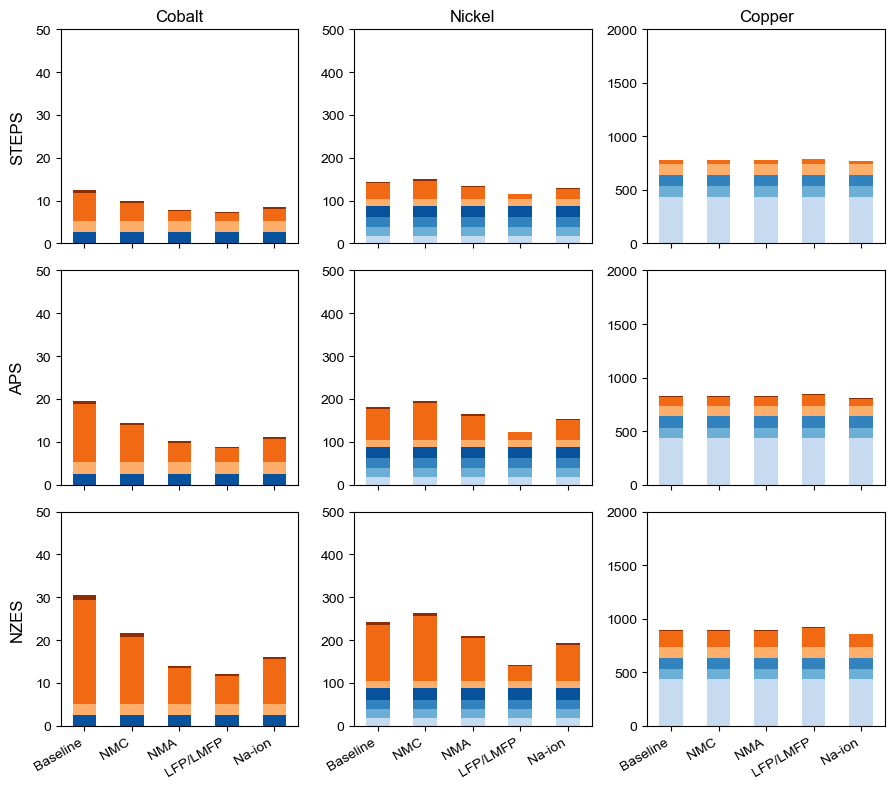

In [46]:
def plot_cum_inflow(df):
    
    fig, axes = plt.subplots(3,3, figsize=(9,8), sharex=True)
    
    for i, iea_sce in enumerate(IEA_Scenarios):
        for j, material in enumerate(Materials):
            
            if material == 'Copper':
                Agg_Sectors = Cu_Agg_Sectors
                Agg_Sector_Colors = Cu_Agg_Sector_Colors
            elif material == 'Nickel':
                Agg_Sectors = Ni_Agg_Sectors
                Agg_Sector_Colors = Ni_Agg_Sector_Colors
            elif material == 'Cobalt':
                Agg_Sectors = Co_Agg_Sectors
                Agg_Sector_Colors = Co_Agg_Sector_Colors

            df_plot = df.loc[(iea_sce),(material)]
            df_plot = df_plot[Agg_Sectors]
            df_plot['X'] = np.arange(0, len(Battery_Scenarios))
            df_plot.plot.bar(ax=axes[i,j], x='X', y=Agg_Sectors, color=Agg_Sector_Colors, stacked=True, legend=False)
            
            if material == 'Copper':
                axes[i,j].set_ylim(0,2000)
            elif material == 'Nickel':
                axes[i,j].set_ylim(0,500)
                #axes[i,j].set_yticks([0, 100, 200, 300, 400, 500])
                df_temp = df_plot.drop(columns=['X'])
                print((df_temp['B-EVs']+df_temp['B-ESS']) / df_temp.sum(axis=1))
            elif material == 'Cobalt':
                axes[i,j].set_ylim(0,50)
                
            axes[i,j].set_xticklabels(Battery_Scenarios, rotation=30, ha='right')  # 设置刻度标签
            axes[i,j].set_xlabel('')
            
            if i == 0:
                axes[i,j].set_title(material)
            if j == 0:
                axes[i,j].annotate(iea_sce, xy=(-0.15, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
                
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_All_Cum_Inflow.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_All_Cum_Inflow.svg', bbox_inches='tight', format='svg')
    plt.show()
    
    
df_temp = plot_cum_inflow(df_optimized_cum_inflow)
df_temp

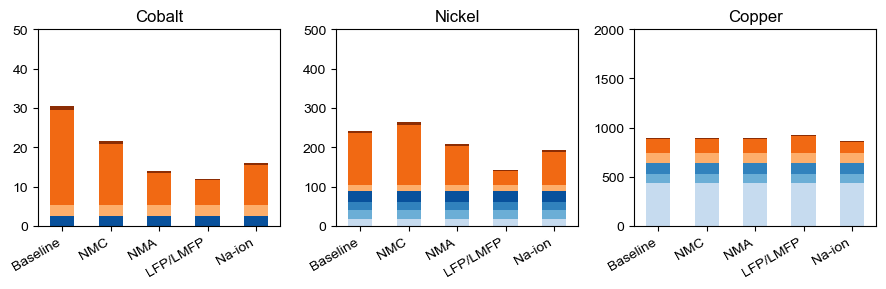

In [47]:
def plot_cum_inflow(df):
    
    fig, axes = plt.subplots(1,3, figsize=(9,3), sharex=True)
    
    iea_sce = 'NZES'
    for j, material in enumerate(Materials):

        if material == 'Copper':
            Agg_Sectors = Cu_Agg_Sectors
            Agg_Sector_Colors = Cu_Agg_Sector_Colors
            axes[j].set_ylim(0,2000)
        elif material == 'Nickel':
            Agg_Sectors = Ni_Agg_Sectors
            Agg_Sector_Colors = Ni_Agg_Sector_Colors
            axes[j].set_ylim(0,500)
        elif material == 'Cobalt':
            axes[j].set_ylim(0,50)
            #axes[j].set_yticks([0,20,40,60,80])
            Agg_Sectors = Co_Agg_Sectors
            Agg_Sector_Colors = Co_Agg_Sector_Colors
            
        df_plot = df.loc[(iea_sce),(material)]
        df_plot = df_plot[Agg_Sectors]
        df_plot['X'] = np.arange(0, len(Battery_Scenarios))
        df_plot.plot.bar(ax=axes[j], x='X', y=Agg_Sectors, color=Agg_Sector_Colors, stacked=True, legend=False)

        axes[j].set_xticklabels(Battery_Scenarios, rotation=30, ha='right')  # 设置刻度标签
        axes[j].set_xlabel('')
        axes[j].set_title(material)
        
       
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_NZES_Cum_Inflow.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_NZES_Cum_Inflow.svg', bbox_inches='tight', format='svg')
    plt.show()
    
    
plot_cum_inflow(df_optimized_cum_inflow)

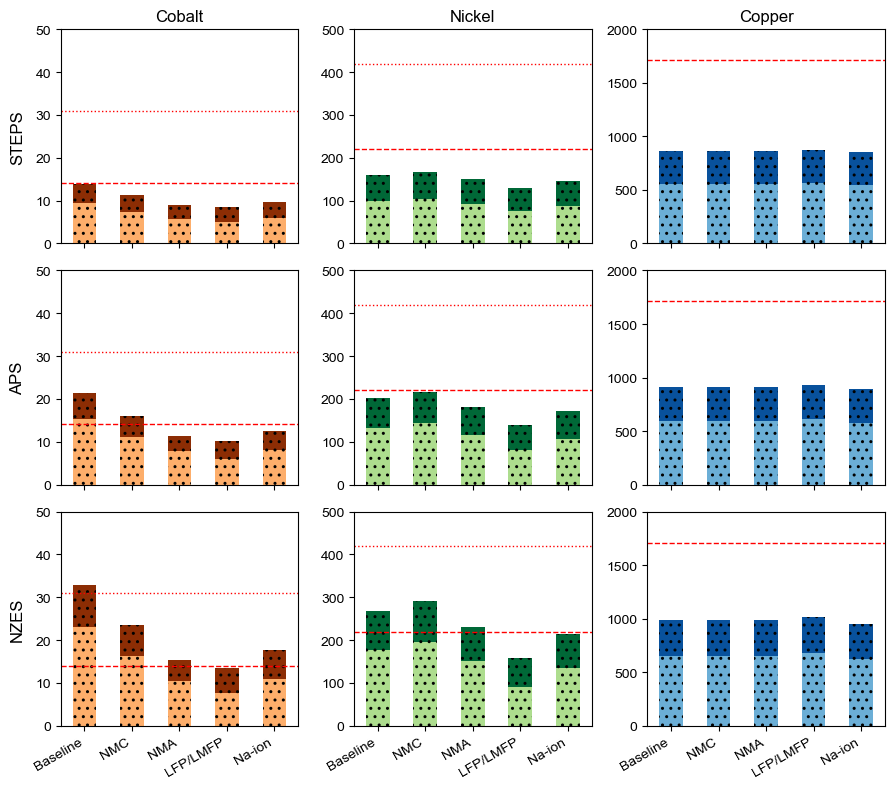

In [48]:
def plot_cum_supply(df_pri, df_sec):
    
    fig, axes = plt.subplots(3,3, figsize=(9,8), sharex=True)
    
    for i, iea_sce in enumerate(IEA_Scenarios):
        for j, material in enumerate(Materials):
            if material == 'Copper':
                Colors = ['#6BAED6','#08519C']
            elif material == 'Nickel':
                Colors = ['#ADDD8E','#006837']
            elif material == 'Cobalt':
                Colors = ['#FDAE6B','#8C2D04']
                
            df_plot = pd.DataFrame(index=Battery_Scenarios, columns=['Primary','Secondary'])
            df_plot.Primary = df_pri.loc[(iea_sce),(material)]
            df_plot.Secondary = df_sec.loc[(iea_sce),(material)]
            
            df_plot['X'] = np.arange(0, len(Battery_Scenarios))
            df_plot.plot.bar(ax=axes[i,j], x='X', color=Colors, stacked=True, legend=False, hatch='..')
            
            if material == 'Copper':
                axes[i,j].set_ylim(0,2000)
                Cu_reserve = 1711.216062  ## Mt
                Cu_resource =  3062.496368  ## Mt
                #axes[i,j].axhline(Cu_resource, color='r', lw=1, linestyle=':')
                axes[i,j].axhline(Cu_reserve, color='r', lw=1, linestyle='--')
                
            elif material == 'Nickel':
                axes[i,j].set_ylim(0,500)
                #axes[i,j].set_yticks([0, 100, 200, 300, 400, 500])
                Ni_reserve = 219.848463  ## Mt
                Ni_resource =  419.859742 ## Mt
                axes[i,j].axhline(Ni_resource, color='r', lw=1, linestyle=':')
                axes[i,j].axhline(Ni_reserve, color='r', lw=1, linestyle='--')
                
            elif material == 'Cobalt':
                axes[i,j].set_ylim(0,50)
                Co_reserve = 14.061897    ## Mt
                Co_resource =  30.986222 ## Mt
                axes[i,j].axhline(Co_resource, color='r', lw=1, linestyle=':')
                axes[i,j].axhline(Co_reserve, color='r', lw=1, linestyle='--')
                Co_pri_supply_SP = 7.3083112492543  ## Mt
                #axes[i,j].axhline(Co_pri_supply_SP, color='r', lw=1, linestyle='-')
                
            axes[i,j].set_xticklabels(Battery_Scenarios, rotation=30, ha='right')  # 设置刻度标签
            axes[i,j].set_xlabel('')
                
            if i == 0:
                axes[i,j].set_title(material)
            if j == 0:
                axes[i,j].annotate(iea_sce, xy=(-0.15, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
                
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_All_Cum_Supply.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_All_Cum_Supply.svg', bbox_inches='tight', format='svg')
    plt.show()
            
        
plot_cum_supply(df_optimized_cum_primary_supply, df_optimized_cum_secondary_supply)

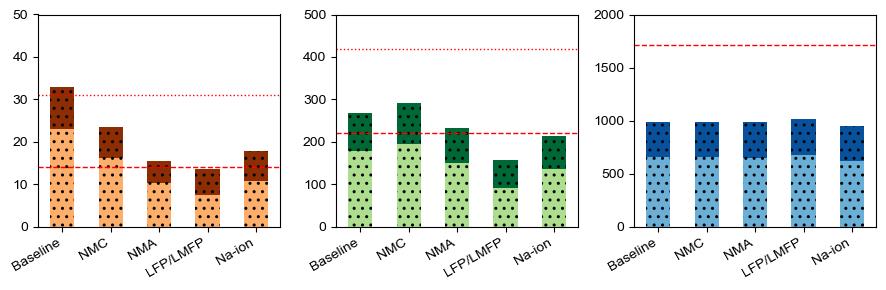

In [49]:
def plot_cum_supply(df_pri, df_sec):
    
    fig, axes = plt.subplots(1,3, figsize=(9,3), sharex=True)
    
    iea_sce = 'NZES'
    for j, material in enumerate(Materials):
        if material == 'Copper':
            Colors = ['#6BAED6','#08519C']
        elif material == 'Nickel':
            Colors = ['#ADDD8E','#006837']
        elif material == 'Cobalt':
            Colors = ['#FDAE6B','#8C2D04']

        df_plot = pd.DataFrame(index=Battery_Scenarios, columns=['Primary','Secondary'])
        df_plot.Primary = df_pri.loc[(iea_sce),(material)]
        df_plot.Secondary = df_sec.loc[(iea_sce),(material)]

        df_plot['X'] = np.arange(0, len(Battery_Scenarios))
        df_plot.plot.bar(ax=axes[j], x='X', color=Colors, stacked=True, legend=False, hatch='..')

        if material == 'Copper':
            axes[j].set_ylim(0,2000)
            Cu_reserve = 1711.216062  ## Mt
            Cu_resource =  3062.496368  ## Mt
            #axes[j].axhline(Cu_resource, color='r', lw=1, linestyle=':')
            axes[j].axhline(Cu_reserve, color='r', lw=1, linestyle='--')
            
        elif material == 'Nickel':
            axes[j].set_ylim(0,500)
            #axes[j].set_yticks([0, 100, 200, 300, 400,500])
            Ni_reserve = 219.848463  ## Mt
            Ni_resource =  419.859742 ## Mt
            axes[j].axhline(Ni_resource, color='r', lw=1, linestyle=':')
            axes[j].axhline(Ni_reserve, color='r', lw=1, linestyle='--')
            
        elif material == 'Cobalt':
            axes[j].set_ylim(0,50)
            #axes[j].set_yticks([0,20,40,60,80])
            Co_reserve = 14.061897    ## Mt
            Co_resource =  30.986222 ## Mt
            axes[j].axhline(Co_resource, color='r', lw=1, linestyle=':')
            axes[j].axhline(Co_reserve, color='r', lw=1, linestyle='--')
            Co_pri_supply_SP = 7.3083112492543  ## Mt
            #axes[j].axhline(Co_pri_supply_SP, color='r', lw=1, linestyle='-')

        axes[j].set_xticklabels(Battery_Scenarios, rotation=30, ha='right')  # 设置刻度标签
        axes[j].set_xlabel('')
        #axes[j].set_title(material)
    
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_NZES_Cum_Supply.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_NZES_Cum_Supply.svg', bbox_inches='tight', format='svg')
    plt.show()
            
        
plot_cum_supply(df_optimized_cum_primary_supply, df_optimized_cum_secondary_supply)

### polt years

In [50]:
def plot_flow_for_a_scenario(ax, df_inflow, df_outflow, material):
    
    ################### inflow by sector
    if material == 'Cobalt':
        Agg_Sectors = Co_Agg_Sectors
        Agg_Sector_Colors = Co_Agg_Sector_Colors
        df_s_i = df_inflow[material].T.groupby(['Sector']).sum().T
    elif material == 'Nickel':
        Agg_Sectors = Ni_Agg_Sectors
        Agg_Sector_Colors = Ni_Agg_Sector_Colors
        df_s_i = df_inflow[material].T.groupby(['Sector']).sum().T / 1000  # from kt to Mt
    elif material == 'Copper':
        Agg_Sectors = Cu_Agg_Sectors
        Agg_Sector_Colors = Cu_Agg_Sector_Colors
        df_s_i = df_inflow[material].T.groupby(['Sector']).sum().T / 1000  # from kt to Mt

    df_s_i['X'] = np.arange(0, 2050-Year_Min+1)
    df_s_i.plot.bar(ax=ax, x='X', xticks=np.arange(0,2050-Year_Min+1,5), y=Agg_Sectors, color=Agg_Sector_Colors, stacked=True, legend=False)
            
    #ax.set_ylabel('Global  '+ material + ' inflows (Mt)')
    ax.set_xticklabels(np.arange(Year_Min,2051,5), rotation='horizontal')
    ax.tick_params(axis='x', labelrotation=0)
            
            
def plot_supply_balance_for_a_scenario(ax, df_s_demand, df_pri_s_p, material):
    
    df_s_demand = df_s_demand.copy()
    df_s_demand.reset_index(inplace=True, drop=True)
    
    df_pri_s_p = df_pri_s_p.copy()
    df_pri_s_p.reset_index(inplace=True, drop=True)
    
    lw = 1
    if material == 'Cobalt':
        ax.plot(df_s_demand.index, (df_s_demand[material+'_Primary'] + df_s_demand[material+'_Secondary_Low'] + df_s_demand[material+'_Secondary_High']), ######################********************
                label='Total requirement', lw=lw, color='k', linestyle='-')  #DC3794
        ax.plot(df_s_demand.index, (df_s_demand[material+'_Secondary_Low'] + df_s_demand[material+'_Secondary_High']), label='Secondary supply', 
                lw=lw, color='k', linestyle='--') 
        ax.plot(df_s_demand.index, (list(df_Primary_Baseline['Total']) + df_s_demand['Cobalt_Secondary_Low'] + df_s_demand['Cobalt_Secondary_High']), ######################********************
                label='Total supply (S&P baseline)', lw=lw, color='r', linestyle='-')
    else:
        ax.plot(df_s_demand.index, (df_s_demand[material+'_Primary'] + df_s_demand[material+'_Secondary_Low'] + df_s_demand[material+'_Secondary_High'])/1000, ######################********************
                label='Total requirement', lw=lw, color='k', linestyle='-')  #DC3794
        ax.plot(df_s_demand.index, (df_s_demand[material+'_Secondary_Low'] + df_s_demand[material+'_Secondary_High'])/1000, label='Secondary supply', ######################********************
                lw=lw, color='k', linestyle='--') 
        df_iea_capacity = df_IEA_prod_capacity.reset_index()
        for year in np.arange(0,20):
            df_iea_capacity.at[year,'Secondary'] = df_s_demand.at[year,material+'_Secondary_Low'] + df_s_demand.at[year,material+'_Secondary_High'] ######################********************
        df_iea_capacity['Total'] = df_iea_capacity[material] + df_iea_capacity.Secondary
        ax.plot(df_iea_capacity.index, df_iea_capacity.Total / 1000, 
                label='Total supply (IEA baseline)', lw=lw, color='r', linestyle='-')

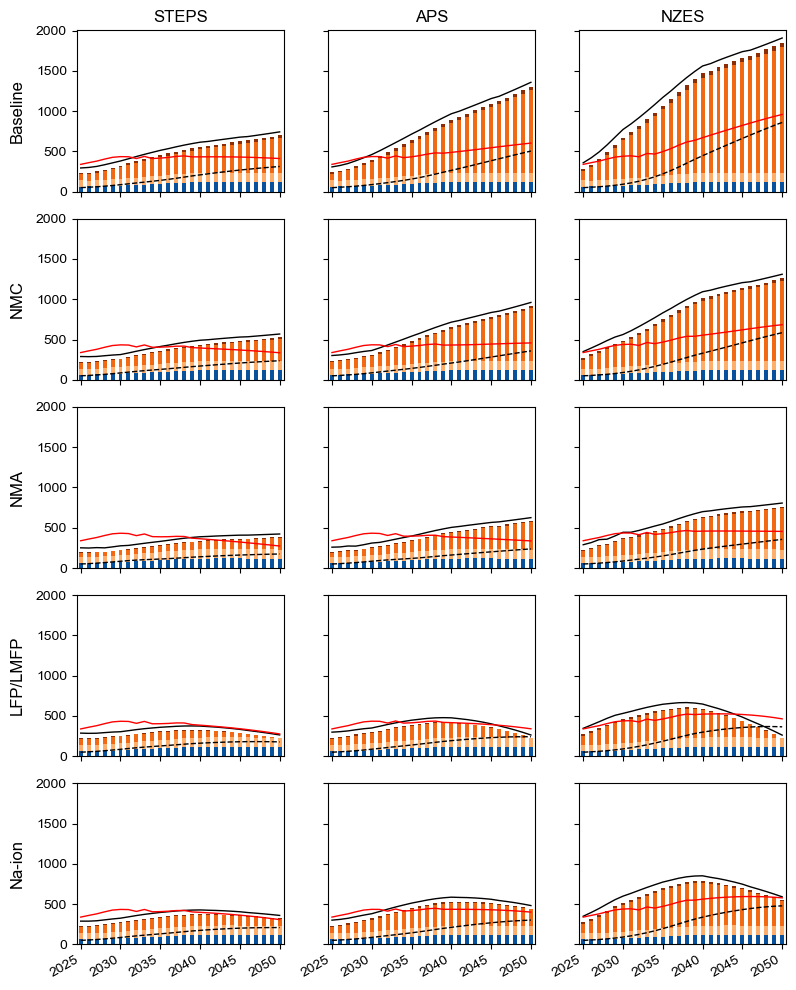

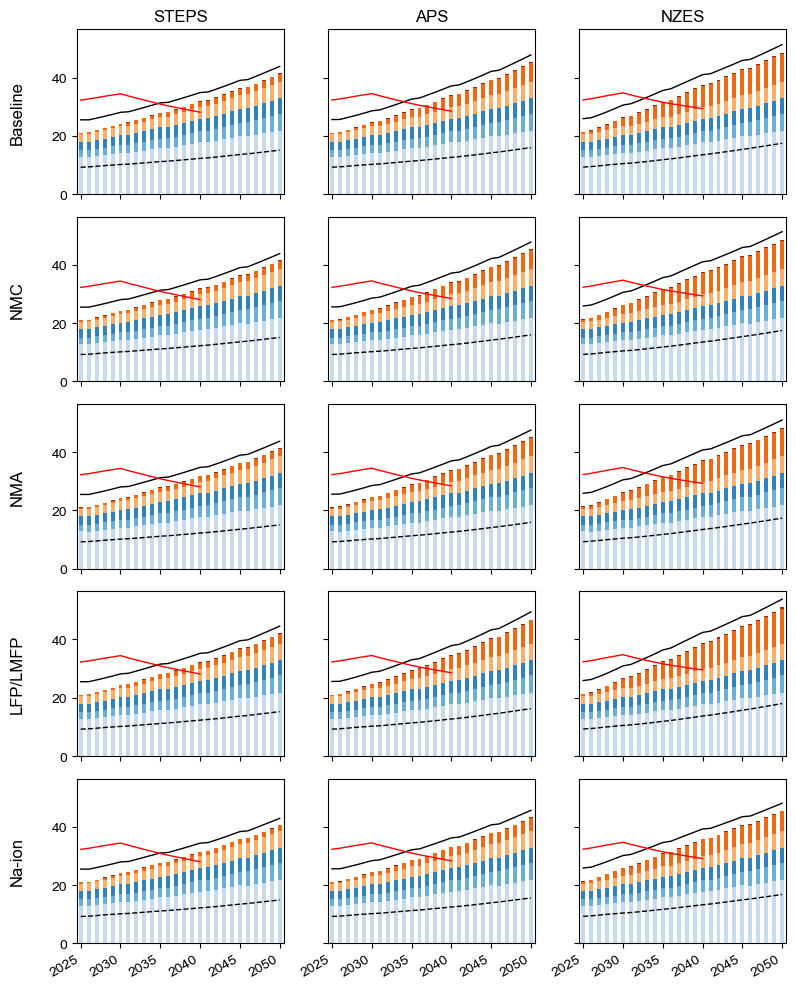

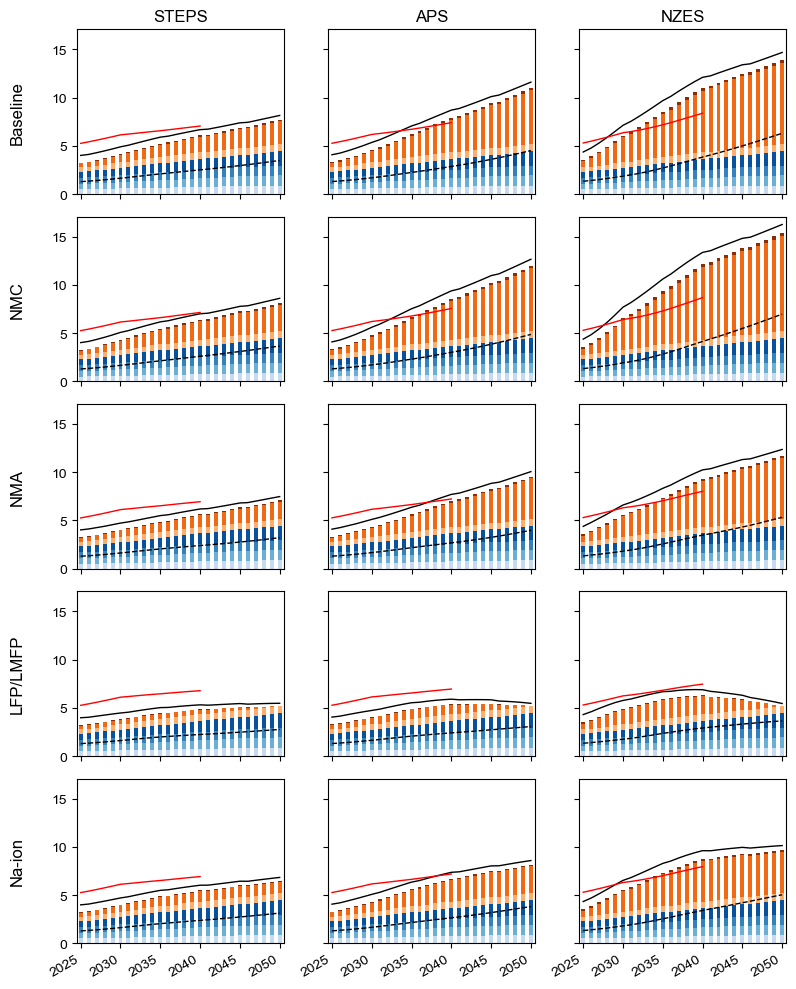

In [51]:
def plot_flow_for_scenarios(material):
    
    fig, axes = plt.subplots(len(Battery_Scenarios),len(IEA_Scenarios), figsize=(8,10), sharex=True, sharey=True)
    
    for i, b_sce in enumerate(Battery_Scenarios):
        for j, iea_sce in enumerate(IEA_Scenarios):
            
            lt='Longer'
            seg_sce='Baseline'
            b_size='Larger'
            
            df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)
            
            df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)
            #df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
            #df_all_sector_stock_2 = reconstruct_sector(df_all_sector_stock)
            df_s_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')            
            df_pri_s_p = cal_cobalt_primary_supply(df_Primary_Baseline, df_s_demand)
            
            plot_flow_for_a_scenario(axes[i,j], df_all_sector_inflow_2, df_all_sector_outflow_2, material)
            plot_supply_balance_for_a_scenario(axes[i,j], df_s_demand, df_pri_s_p, material)
            
            axes[i,j].set_xlabel('')
            axes[i,j].set_xticks(np.arange(0,26,5))
            axes[i,j].set_xticklabels(np.arange(2025,2051,5), rotation=30, ha='right')  # 设置刻度标签
            if i == 0:
                axes[i,j].set_title(iea_sce)
            if j == 0:
                axes[i, j].annotate(b_sce, xy=(-0.25, 0.5), xycoords='axes fraction', 
                                    ha='right', va='center', fontsize=axes[i, 0].title.get_fontsize(), rotation=90)
                
    #为最后一个子图添加 legend
    #handles, labels = axes[-1,-1].get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5, -0.02), frameon=False)
    
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_Year_'+material+'.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.show()
    

## unit: Mt
plot_flow_for_scenarios(material='Cobalt')
plot_flow_for_scenarios(material='Copper')
plot_flow_for_scenarios(material='Nickel')

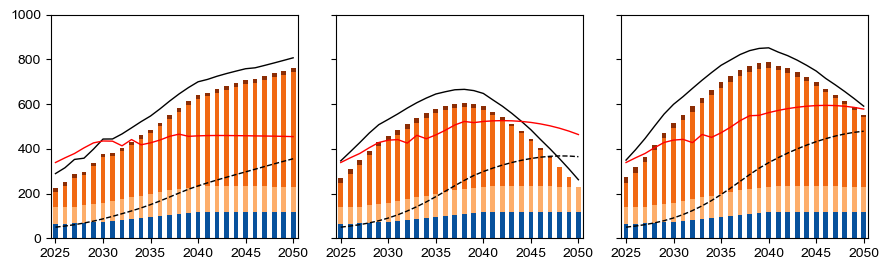

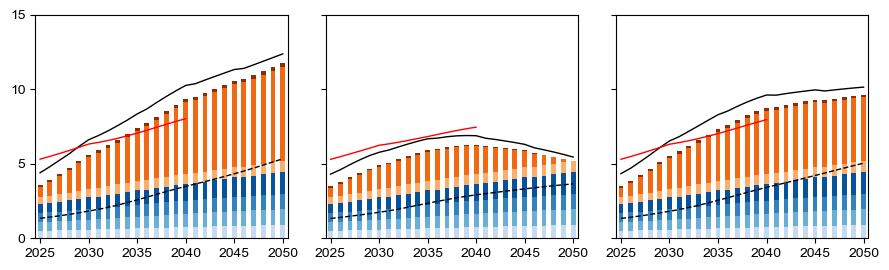

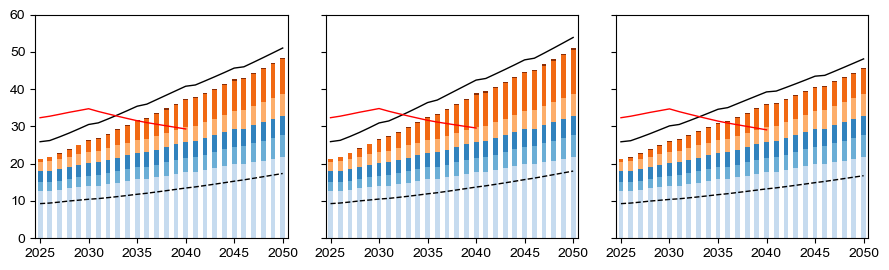

In [52]:
def plot_flow_for_scenarios(material):
    
    New_Battery_Scenarios = ['NMA', 'LFP/LMFP', 'Na-ion']
    #New_Battery_Scenarios = ['NMC', 'NMA', 'LFP/LMFP', 'Na-ion']
    fig, axes = plt.subplots(1,len(New_Battery_Scenarios), figsize=(9,2.8), sharex=True, sharey=True)
    
    for i, b_sce in enumerate(New_Battery_Scenarios):
        iea_sce = 'NZES' 
        lt='Longer'
        seg_sce='Baseline'
        b_size='Larger'

        df_all_sector_inflow = extract_all_sectors(flow='Inflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
        df_all_sector_inflow_2 = reconstruct_sector(df_all_sector_inflow)

        df_all_sector_outflow = extract_all_sectors(flow='Outflow', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
        df_all_sector_outflow_2 = reconstruct_sector(df_all_sector_outflow)
        #df_all_sector_stock = extract_all_sectors(flow='Stock', lt=lt, d_sce=iea_sce, seg_sce=seg_sce, b_size=b_size, b_sce=b_sce)
        #df_all_sector_stock_2 = reconstruct_sector(df_all_sector_stock)
        df_s_demand = cal_all_metal_demand(df_all_sector_inflow, df_all_sector_outflow, df_Co_Surplus, secondary_sce='High', process_sce='Efficient')            
        df_pri_s_p = cal_cobalt_primary_supply(df_Primary_Baseline, df_s_demand)

        plot_flow_for_a_scenario(axes[i], df_all_sector_inflow_2, df_all_sector_outflow_2, material)
        plot_supply_balance_for_a_scenario(axes[i], df_s_demand, df_pri_s_p, material)

        axes[i].set_xlabel('')
        #axes[i].set_title(b_sce)
        
        if material == 'Cobalt':
            axes[i].set_ylim(0,1000)
        elif material == 'Nickel':
            axes[i].set_ylim(0,15)
            axes[i].yaxis.set_major_locator(FixedLocator([0, 5, 10, 15]))
            axes[i].yaxis.set_minor_locator(NullLocator())
        elif material == 'Copper':
            axes[i].set_ylim(0,60)

        if material == 'Cobalt':
            with pd.ExcelWriter(file_path + 'Scenarios/plot_Strategy/Combined/Combined_extended_Fig4_'+b_sce[:3]+'_.xlsx') as writer:
                df_all_sector_inflow_2.to_excel(excel_writer = writer, sheet_name='Annual_inflow')
                df_s_demand.to_excel(excel_writer = writer, sheet_name='Supply_Demand')
                df_pri_s_p.to_excel(excel_writer = writer, sheet_name='Primary_Supply_Potential')

    #为最后一个子图添加 legend
    #handles, labels = axes[-1].get_legend_handles_labels()
    #fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, -0.02), frameon=False)
    
    plt.tight_layout()
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_NZES'+material+'.png', bbox_inches='tight', pad_inches=.1, dpi=500)
    plt.savefig(file_path + 'Scenarios/plot_Strategy/Combined/Combined_NZES'+material+'.svg', bbox_inches='tight', format='svg')
    plt.show()
    

## unit: kt
plot_flow_for_scenarios(material='Cobalt')
plot_flow_for_scenarios(material='Nickel')
plot_flow_for_scenarios(material='Copper')

In [53]:
with pd.ExcelWriter(file_path + 'Scenarios/plot_Strategy/Combined/Combined_extended_Fig3.xlsx') as writer:
    
    df_optimized_cum_inflow.to_excel(excel_writer = writer, sheet_name='Cum_inflow')
    df_optimized_cum_primary_supply.to_excel(excel_writer = writer, sheet_name='Cum_primary')
    df_optimized_cum_secondary_supply.to_excel(excel_writer = writer, sheet_name='Cum_secondary')

In [54]:
end_time = time.time()
execution_time = end_time - start_time
hours = execution_time // 3600 
minutes = (execution_time % 3600) // 60 
seconds = execution_time % 60 

print(f"代码运行时间: {int(hours)}小时 {int(minutes)}分钟 {int(seconds)}秒")

代码运行时间: 0小时 1分钟 35秒
